In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import arrow
from pathlib import Path
import netCDF4 as nc
import pandas as pd
import numpy as np
from cmocean import cm
from salishsea_tools import viz_tools
from mpl_toolkits.axes_grid1 import make_axes_locatable
import gsw
import os

In [4]:
grid_dir = Path("/ocean/atall/MOAD/grid/")
grid_map = Path("grid_from_lat_lon_mask999.nc")
grid_lons_lats = xr.open_dataset(grid_dir / grid_map)
meshmask0 = xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask_202310b.nc')
meshmask = xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask202605.nc')
tmask0 = meshmask0.tmask
mbathy0 = meshmask0.mbathy
tmask1 = meshmask.tmask
mbathy1 = meshmask.mbathy

mesh = nc.Dataset('/ocean/atall/MOAD/grid/mesh_mask202605.nc')
bathy = nc.Dataset('/ocean/atall/MOAD/grid/bathymetry_202605.nc')
depth = mesh.variables['gdept_1d'][:]


### HOOD CANAL - Ecology data

In [5]:
stations = {
#    'HCB003': (-123.00830, 47.53833),
    'HCB004': (-123.02330, 47.35667),
    'HCB007': (-122.928299, 47.398331),
}
stations_Sources = {
    'HCB003': (-123.00830, 47.53833),
    'ADM003': (-122.48180, 47.87917),
    'SAR003': (-122.49000, 48.10833),
    'SKG003': (-122.48830, 48.29667),
}
stationsPC = {                         # Penn Cove stations: to be used for the map and for the evaluation of the model at the station locations
    'PENNCOVEENT': (-122.655, 48.2370),
    'PENNCOVEPNN001': (-122.670, 48.2300),
    'PENNCOVECW': (-122.688, 48.2230),
    'PENNCOVEWEST': (-122.720, 48.2249),
}
station_indices, station_indices_Sources, station_indicesPC = {}, {}, {}

for name, (lon_sta, lat_sta) in stations.items():

    jj = grid_lons_lats.jj.sel(lats=lat_sta, lons=lon_sta, method='nearest').item()

    ii = grid_lons_lats.ii.sel(lats=lat_sta, lons=lon_sta, method='nearest').item()

    station_indices[name] = (jj, ii)

    print(name, bathy['Bathymetry'][jj, ii])

for name, (lon_sta, lat_sta) in stations_Sources.items():

    jj = grid_lons_lats.jj.sel(lats=lat_sta, lons=lon_sta, method='nearest').item()

    ii = grid_lons_lats.ii.sel(lats=lat_sta, lons=lon_sta, method='nearest').item()

    station_indices_Sources[name] = (jj, ii)

    print(name, bathy['Bathymetry'][jj, ii])

for name, (lon_sta, lat_sta) in stationsPC.items():

    jj = grid_lons_lats.jj.sel(lats=lat_sta, lons=lon_sta, method='nearest').item()

    ii = grid_lons_lats.ii.sel(lats=lat_sta, lons=lon_sta, method='nearest').item()

    station_indicesPC[name] = (jj, ii)

    print(name, bathy['Bathymetry'][jj, ii])

HCB004 50.0625
HCB007 22.625
HCB003 122.0
ADM003 201.3125
SAR003 135.0
SKG003 19.25
PENNCOVEENT 23.625
PENNCOVEPNN001 26.25
PENNCOVECW 13.125
PENNCOVEWEST 12.25


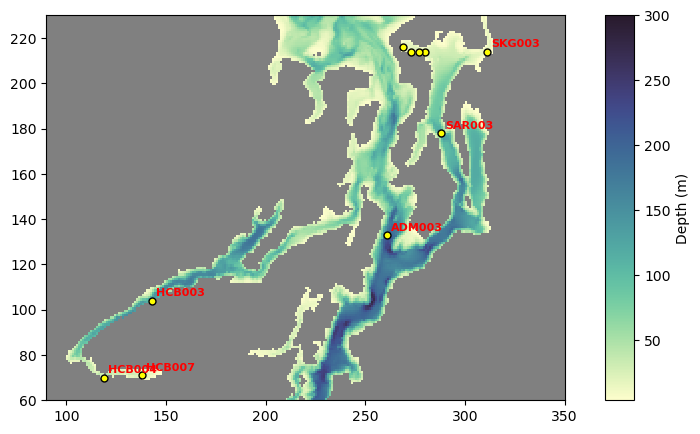

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

mycmap = cm.deep
mycmap.set_bad('grey')

ax.set_xlim([90, 350])
ax.set_ylim([60, 230])

vmin, vmax = (4, 300)

im = ax.pcolormesh(bathy.variables['Bathymetry'][:], cmap=mycmap, vmin=vmin, vmax=vmax)

for name, (jj, ii) in station_indices.items():

    ax.plot(ii, jj, marker='o', color='yellow', markersize=5, markeredgecolor='black')

    ax.text(ii + 2, jj + 2, name, fontsize=8, color='red', weight='bold')

    viz_tools.set_aspect(ax)
for name, (jj, ii) in station_indices_Sources.items():

    ax.plot(ii, jj, marker='o', color='yellow', markersize=5, markeredgecolor='black')

    ax.text(ii + 2, jj + 2, name, fontsize=8, color='red', weight='bold')

    viz_tools.set_aspect(ax)
for name, (jj, ii) in station_indicesPC.items():

    ax.plot(ii, jj, marker='o', color='yellow', markersize=5, markeredgecolor='black')

    #ax.text(ii + 2, jj + 2, name, fontsize=8, color='red', weight='bold')

    viz_tools.set_aspect(ax)

divider = make_axes_locatable(ax)

cax = divider.append_axes('right', size='5%', pad=0.05)

fig.colorbar(im, cax=cax, orientation='vertical', label='Depth (m)')

In [6]:

obs_2012 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20120101_20121231.csv'
)
obs_2013 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20130101_20131231.csv'
)
obs_2014 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20140101_20141231.csv'
)
obs_2015 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20150101_20151231.csv'
)
obs_2016 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20160101_20161231.csv'
)
obs_2017 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20170101_20171231.csv'
)
obs_2018 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20180101_20181231.csv'
)
obs_2019 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20190101_20191231.csv'
)
obs_2020 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20200101_20201231.csv'
)
obs_2021 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20210101_20211231.csv'
)
obs_2022 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20220101_20221231.csv'
)
obs_2023 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20230101_20231231.csv'
)
obs_2024 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20240101_20241231.csv'
)
obs = pd.concat([obs_2012, obs_2013, obs_2014, obs_2015, obs_2016, obs_2017, obs_2018, obs_2019, obs_2020, obs_2021, obs_2022, obs_2023, obs_2024], ignore_index=True)
obs['dtUTC'] = pd.to_datetime(obs['dtUTC'])

obs.head()

,cid,cruise,dtUTC,Lat,Lon,name,Z,Temperature,Salinity,Oxygen_Dissolved,...,mod_silicon,mod_ammonium,mod_diatoms,mod_flagellates,mod_vosaline,mod_votemper,mod_total_alkalinity,mod_dissolved_inorganic_carbon,mod_dissolved_oxygen,k
0,0.0,NaN,2012-01-10 17:38:08,47.091671,-122.916702,BUD005,1.0,8.404476,28.058271,257.19376,...,49.431503,5.687942,0.331648,0.185149,25.972794,7.057947,1908.247437,1830.361206,267.866913,0
1,0.0,NaN,2012-01-10 17:38:08,47.091671,-122.916702,BUD005,10.0,8.784269,28.883365,236.59375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2,13.0,NaN,2012-01-11 17:57:20,48.011669,-122.300003,PSS019,1.5,7.669921,22.556616,313.95935,...,69.019226,5.320978,0.270968,0.197008,19.750334,6.081752,1606.858887,1566.570435,314.779297,1
3,13.0,NaN,2012-01-11 17:57:20,48.011669,-122.300003,PSS019,10.5,9.584160,29.472389,221.81563,...,48.208279,3.810591,0.191718,0.187119,29.102438,8.926137,2069.521240,2005.694092,225.699371,10
4,13.0,NaN,2012-01-11 17:57:20,48.011669,-122.300003,PSS019,96.0,9.089665,30.303685,220.89375,...,48.352821,3.549863,0.052504,0.051540,30.456875,9.515012,2136.673584,2090.629395,151.329575,26


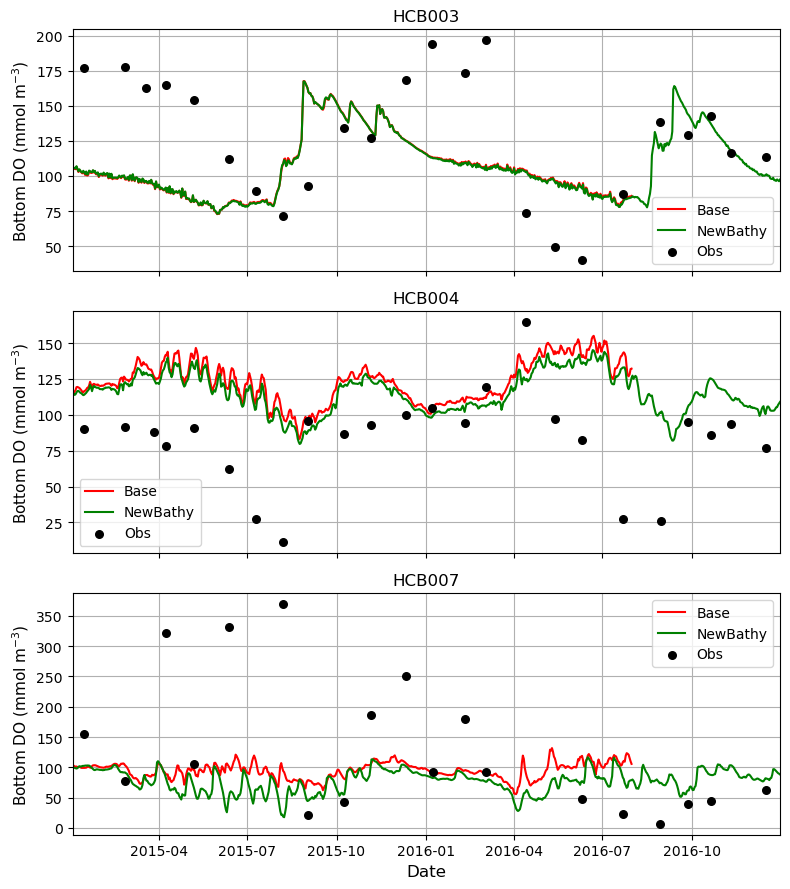

In [ ]:
place = list(stations.keys())

fig, ax = plt.subplots(
    len(place),
    1,
    figsize=(8, 6),
    sharex=True
)
syear, smonth, sday = (2015, 1, 2)
eyear, emonth, eday = (2016, 12, 31)
startdate = arrow.get(syear, smonth, sday)
enddate1   = arrow.get(eyear, emonth, eday)
enddate0   = arrow.get(eyear, 7, 31)
ylabel = 'Bottom DO (mmol m$^{-3}$)'

simulations = [
    {
        'dir': '/ocean/atall/MOAD/Model/202410b_updated/',
        'color': 'red',
        'label': 'Base',
        'mbathy': mbathy0,
        'tmask': tmask0,
    },
    {
        'dir': '/ocean/atall/MOAD/Model/202410b_NewBathyHC/notNOAA/',
        'color': 'green',
        'label': 'NewBathy',
        'mbathy': mbathy1,
        'tmask': tmask1,
    },
    
]
for sim in simulations:

    sim_dir = sim['dir']
    color   = sim['color']
    label   = sim['label']
    mbathy  = sim['mbathy']
    tmask   = sim['tmask']

    if label == 'Base':
        enddate = enddate0
    else:
        enddate = enddate1



    for j, station_name in enumerate(place):

        jj, ii = station_indices[station_name]

        oxy_list = []
        time_list = []

        for day_arrow in arrow.Arrow.range('day', startdate, enddate):
            year  = day_arrow.year
            yr2   = day_arrow.strftime("%y")
            month = day_arrow.month
            Month = day_arrow.strftime("%b").lower()
            day   = day_arrow.day

            fchem = (
                f'{sim_dir}{day:02}{Month}{yr2}/'
                f'SalishSea_1d_'
                f'{year}{month:02}{day:02}_'
                f'{year}{month:02}{day:02}_chem_T.nc'
            )
            with xr.open_dataset(fchem) as ds_chem:
                k = int(mbathy[0, jj, ii] - 1)
                oxy_val = ds_chem['dissolved_oxygen'][0, k, jj, ii].values
                oxy_list.append(float(oxy_val))
                time_list.append(day_arrow.datetime)

        ax[j].plot(time_list, oxy_list, color=color, label=label, linewidth=1.5)
for j, station_name in enumerate(place):
    obs_station = obs[obs['name'] == station_name].copy()
    obs_station['date_only'] = obs_station['dtUTC'].dt.date

    idx_bottom = (obs_station.groupby('date_only')['Z'].idxmax())
    obs_bottom = obs_station.loc[idx_bottom]

    ax[j].scatter(obs_bottom['dtUTC'], obs_bottom['Oxygen_Dissolved'], color='k', s=30, label='Obs', zorder=10)
    ax[j].set_ylabel(ylabel, fontsize=11)
    ax[j].set_title(station_name, fontsize=12)
    ax[j].grid(True)
    ax[j].legend()
    ax[j].set_xlim(startdate.datetime, enddate1.datetime)

ax[-1].set_xlabel('Date', fontsize=12)

plt.tight_layout()

plt.show()


#### Sources stations: surface & bottom timeseries

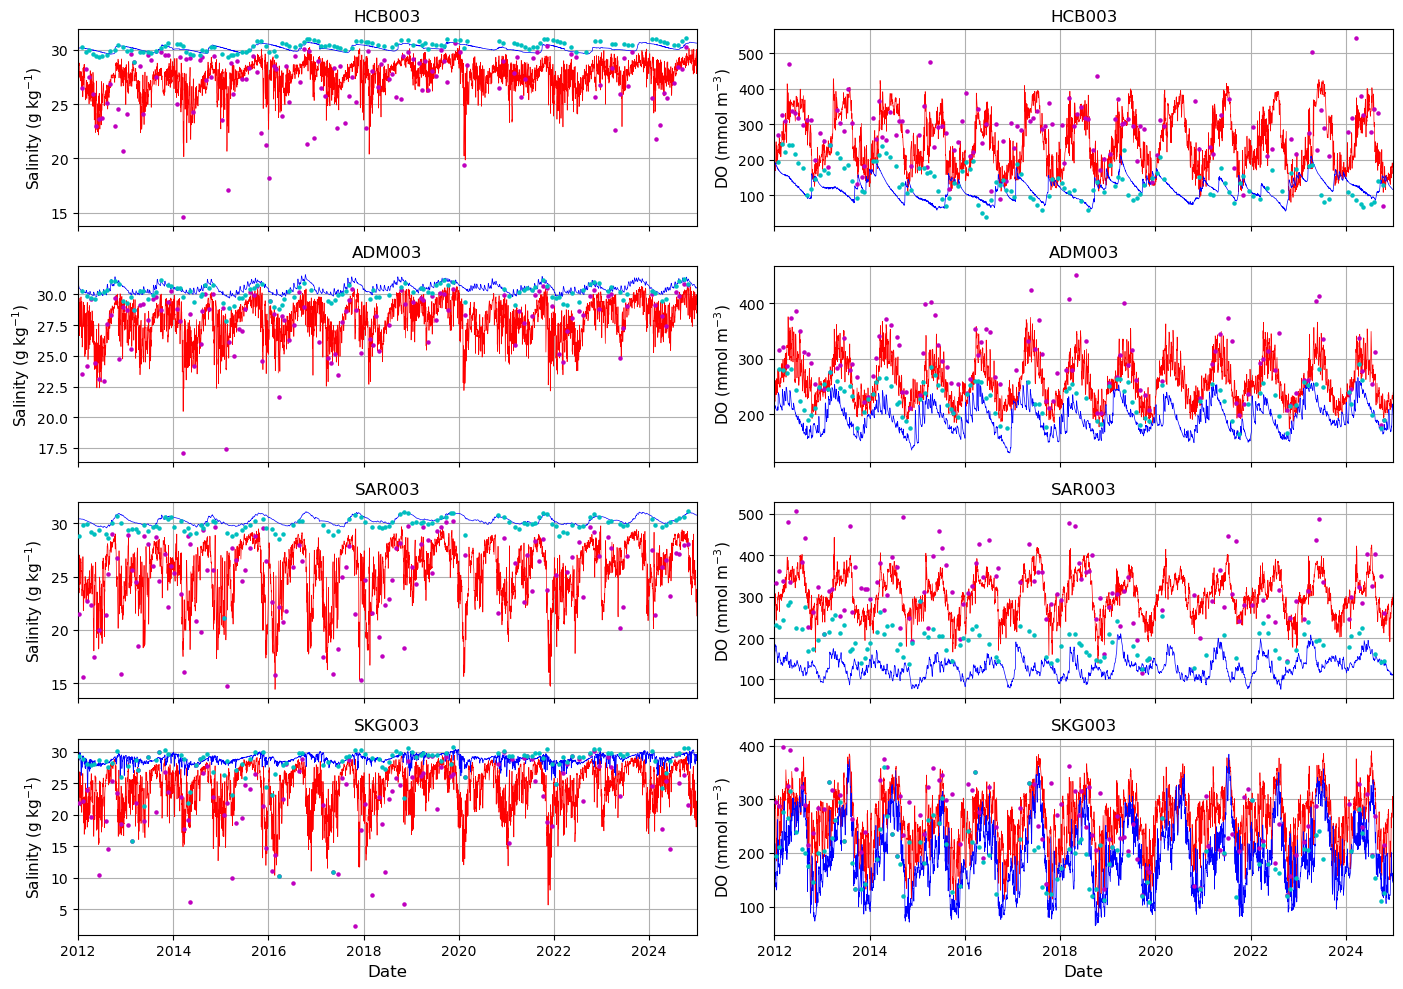

In [12]:
place_Sources = list(stations_Sources.keys())

fig, ax = plt.subplots(
    len(place_Sources),
    2,
    figsize=(14, 10),
    sharex=True
)

#sim_dir = '/ocean/atall/MOAD/Model/202410b_updated/'
sim_dir = '/ocean/atall/MOAD/Model/202410b/oxygen/'
mbathy = mbathy0 # To be updated to mbathy1 once it's ready

syear, smonth, sday = (2012, 1, 1)
eyear, emonth, eday = (2024, 12, 31)
startdate = arrow.get(syear, smonth, sday)
enddate   = arrow.get(eyear, emonth, eday)
ylabel = 'Bottom DO (mmol m$^{-3}$)'

for j, station_nameSources in enumerate(place_Sources):

    jj, ii = station_indices_Sources[station_nameSources]

    oxyS_list, oxyB_list = [], []
    SalS_list, SalB_list = [], []
    time_list = []

    for day_arrow in arrow.Arrow.range('day', startdate, enddate):
        year  = day_arrow.year
        yr2   = day_arrow.strftime("%y")
        month = day_arrow.month
        Month = day_arrow.strftime("%b").lower()
        day   = day_arrow.day

        fgrid = (
            f'{sim_dir}{day:02}{Month}{yr2}/'
            f'SalishSea_1d_'
            f'{year}{month:02}{day:02}_'
            f'{year}{month:02}{day:02}_grid_T.nc'
        )
        with xr.open_dataset(fgrid) as ds_grid:
            k = int(mbathy[0, jj, ii] - 1)
            SalS_val = ds_grid['vosaline'][0, 4, jj, ii].values
            SalB_val = ds_grid['vosaline'][0, k, jj, ii].values
            SalS_list.append(float(SalS_val))
            SalB_list.append(float(SalB_val))
            time_list.append(day_arrow.datetime)
        fchem = (
            f'{sim_dir}{day:02}{Month}{yr2}/'
            f'SalishSea_1d_'
            f'{year}{month:02}{day:02}_'
            f'{year}{month:02}{day:02}_chem_T.nc'
        )
        with xr.open_dataset(fchem) as ds_chem:
            k = int(mbathy[0, jj, ii] - 1)
            oxyS_val = ds_chem['dissolved_oxygen'][0, 4, jj, ii].values
            oxyB_val = ds_chem['dissolved_oxygen'][0, k, jj, ii].values
            oxyS_list.append(float(oxyS_val))
            oxyB_list.append(float(oxyB_val))

    ax[j,0].plot(time_list, SalS_list, color='r', linewidth=0.5)
    ax[j,0].plot(time_list, SalB_list, color='b', linewidth=0.5)
    ax[j,1].plot(time_list, oxyS_list, color='r', linewidth=0.5)
    ax[j,1].plot(time_list, oxyB_list, color='b', linewidth=0.5)
for j, station_nameSources in enumerate(place_Sources):
    obs_station = obs[obs['name'] == station_nameSources].copy()
    obs_station['date_only'] = obs_station['dtUTC'].dt.date

    idx_surface = (obs_station.groupby('date_only')['Z'].idxmin())
    obs_surface = obs_station.loc[idx_surface]
    idx_bottom = (obs_station.groupby('date_only')['Z'].idxmax())
    obs_bottom = obs_station.loc[idx_bottom]

    ax[j,0].scatter(obs_surface['dtUTC'], obs_surface['Salinity'], color='m', s=5, label='Surface', zorder=10)
    ax[j,0].scatter(obs_bottom['dtUTC'], obs_bottom['Salinity'], color='c', s=5, label='Bottom', zorder=10)
    ax[j,1].scatter(obs_surface['dtUTC'], obs_surface['Oxygen_Dissolved'], color='m', s=5, label='Surface', zorder=10)
    ax[j,1].scatter(obs_bottom['dtUTC'], obs_bottom['Oxygen_Dissolved'], color='c', s=5, label='Bottom', zorder=10)
    ax[j,0].set_ylabel('Salinity (g kg$^{-1}$)', fontsize=11)
    ax[j,1].set_ylabel('DO (mmol m$^{-3}$)', fontsize=11)
    ax[j,0].set_title(station_nameSources, fontsize=12)
    ax[j,1].set_title(station_nameSources, fontsize=12)
    ax[j,0].grid(True)
    ax[j,1].grid(True)
    #ax[j,0].legend()
    ax[j,0].set_xlim(startdate.datetime, enddate.datetime)
    ax[j,1].set_xlim(startdate.datetime, enddate.datetime)

ax[-1,0].set_xlabel('Date', fontsize=12)
ax[-1,1].set_xlabel('Date', fontsize=12)

plt.tight_layout()

plt.show()

#### Penn Cove - KC data - 2022 only

In [15]:
obs_pc = pd.read_csv("/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410_from_KC_20220101_20221231.csv")
obs_pc["dtUTC"] = pd.to_datetime(obs_pc["dtUTC"])
obs_pc.head()

,Unnamed: 0.1,Unnamed: 0,Z,Locator,CH Qual,DO Qual,NO23 Qual,SA Qual,Sample Date,Summ Row ID,...,i,mod_nitrate,mod_silicon,mod_ammonium,mod_diatoms,mod_flagellates,mod_vosaline,mod_votemper,mod_dissolved_oxygen,k
0,0,496,1.0,PENNCOVEENT,NaN,NaN,NaN,NaN,02/03/2022 12:12:59 PM,NaN,...,280,18.927807,75.319954,5.982275,0.391633,0.252204,16.112215,5.415637,320.648926,0
1,1,497,2.0,PENNCOVEENT,NaN,NaN,NaN,NaN,02/03/2022 12:13:38 PM,NaN,...,280,18.928608,75.311386,5.981601,0.393443,0.252248,16.114300,5.419223,320.547577,1
2,2,498,2.5,PENNCOVEENT,NaN,NaN,NaN,NaN,02/03/2022 12:13:41 PM,NaN,...,280,18.956282,75.145309,5.972476,0.410120,0.253138,16.165976,5.464930,320.093262,2
3,3,499,3.0,PENNCOVEENT,NaN,NaN,NaN,NaN,02/03/2022 12:13:43 PM,NaN,...,280,18.956282,75.145309,5.972476,0.410120,0.253138,16.165976,5.464930,320.093262,2
4,4,500,3.5,PENNCOVEENT,NaN,NaN,NaN,NaN,02/03/2022 12:13:45 PM,NaN,...,280,19.395243,73.407227,5.969169,0.446182,0.262371,16.768141,5.507122,324.039368,3


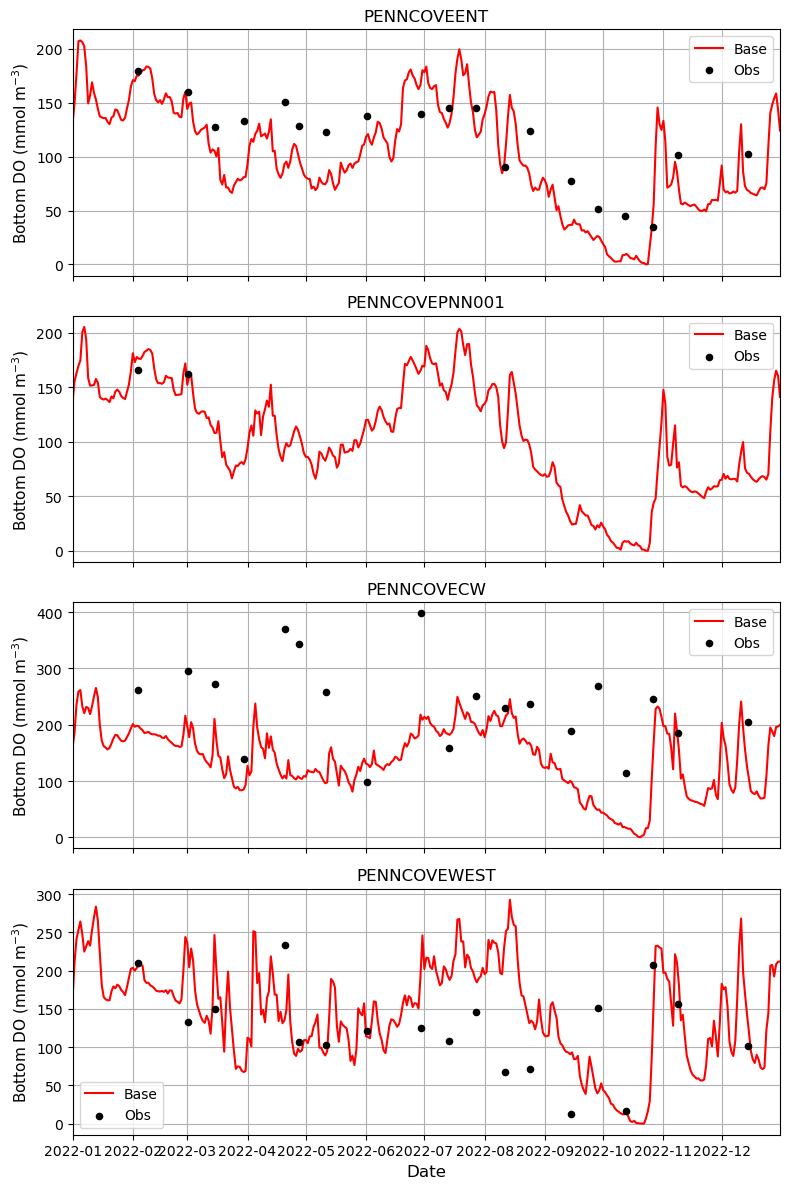

In [ ]:
placePC = list(stationsPC.keys())

fig, ax = plt.subplots(
    len(placePC),
    1,
    figsize=(8, 12),
    sharex=True
)
simulationsPC = [
    {
        'dir': '/ocean/atall/MOAD/Model/202410b/oxygen/',
        'color': 'red',
        'label': 'Base',
        'mbathy': mbathy0,
        'tmask': tmask0,
    }
]
syear, smonth, sday = (2022, 1, 1)
eyear, emonth, eday = (2022, 12, 31)
startdate = arrow.get(syear, smonth, sday)
enddate   = arrow.get(eyear, emonth, eday)
ylabel = 'Bottom DO (mmol m$^{-3}$)'

for sim in simulationsPC:

    sim_dir = sim['dir']
    color   = sim['color']
    label   = sim['label']
    mbathy  = sim['mbathy']
    tmask   = sim['tmask']

    for j, station_namePC in enumerate(placePC):

        jj, ii = station_indicesPC[station_namePC]

        oxy_list = []
        time_list = []

        for day_arrow in arrow.Arrow.range('day', startdate, enddate):
            year  = day_arrow.year
            yr2   = day_arrow.strftime("%y")
            month = day_arrow.month
            Month = day_arrow.strftime("%b").lower()
            day   = day_arrow.day

            fchem = (
                f'{sim_dir}{day:02}{Month}{yr2}/'
                f'SalishSea_1d_'
                f'{year}{month:02}{day:02}_'
                f'{year}{month:02}{day:02}_chem_T.nc'
            )
            with xr.open_dataset(fchem) as ds_chem:
                k = int(mbathy[0, jj, ii] - 1)
                oxy_val = ds_chem['dissolved_oxygen'][0, k, jj, ii].values
                oxy_list.append(float(oxy_val))
                time_list.append(day_arrow.datetime)

        ax[j].plot(time_list, oxy_list, color=color, label='Model', linewidth=1.5)
for j, station_namePC in enumerate(placePC):
    
    obs_stationPC = obs_pc[obs_pc['Locator'] == station_namePC].copy()
    
    obs_stationPC['date_only'] = obs_stationPC['dtUTC'].dt.date
    
    idx_bottom_obs = obs_stationPC.groupby('date_only')['Z'].idxmax()
    obs_bottom = obs_stationPC.loc[idx_bottom_obs]

    ax[j].scatter(obs_bottom['dtUTC'], obs_bottom['Oxygen_Dissolved'], color='k', marker='o', s=20, label='Obs',zorder=10)

    ax[j].set_ylabel(ylabel, fontsize=11)
    ax[j].set_title(station_namePC, fontsize=12)
    ax[j].grid(True)
    ax[j].legend()
    ax[j].set_xlim(startdate.datetime, enddate.datetime)

ax[-1].set_xlabel('Date', fontsize=12)

plt.tight_layout()

plt.show()

#### Profiles: Source Water, Lynch Cove, Penn Cove

In [17]:
def get_season(month):
    if month in [12, 1, 2]:   return 'Winter'
    elif month in [3, 4, 5]:  return 'Spring'
    elif month in [6, 7, 8]:  return 'Summer'
    else:                     return 'Fall'

obs['season'] = obs['dtUTC'].dt.month.map(get_season)
obs_pc['season'] = obs_pc['dtUTC'].dt.month.map(get_season)
columns_list = ['Winter', 'Spring', 'Summer', 'Fall', 'Annual']

list_obs = list(stations.keys())      
list_obs_sources = list(stations_Sources.keys())  
list_obs_pc = list(stationsPC.keys())  

sim_dir = '/ocean/atall/MOAD/Model/202410b/oxygen/' # To be changed to the updated version

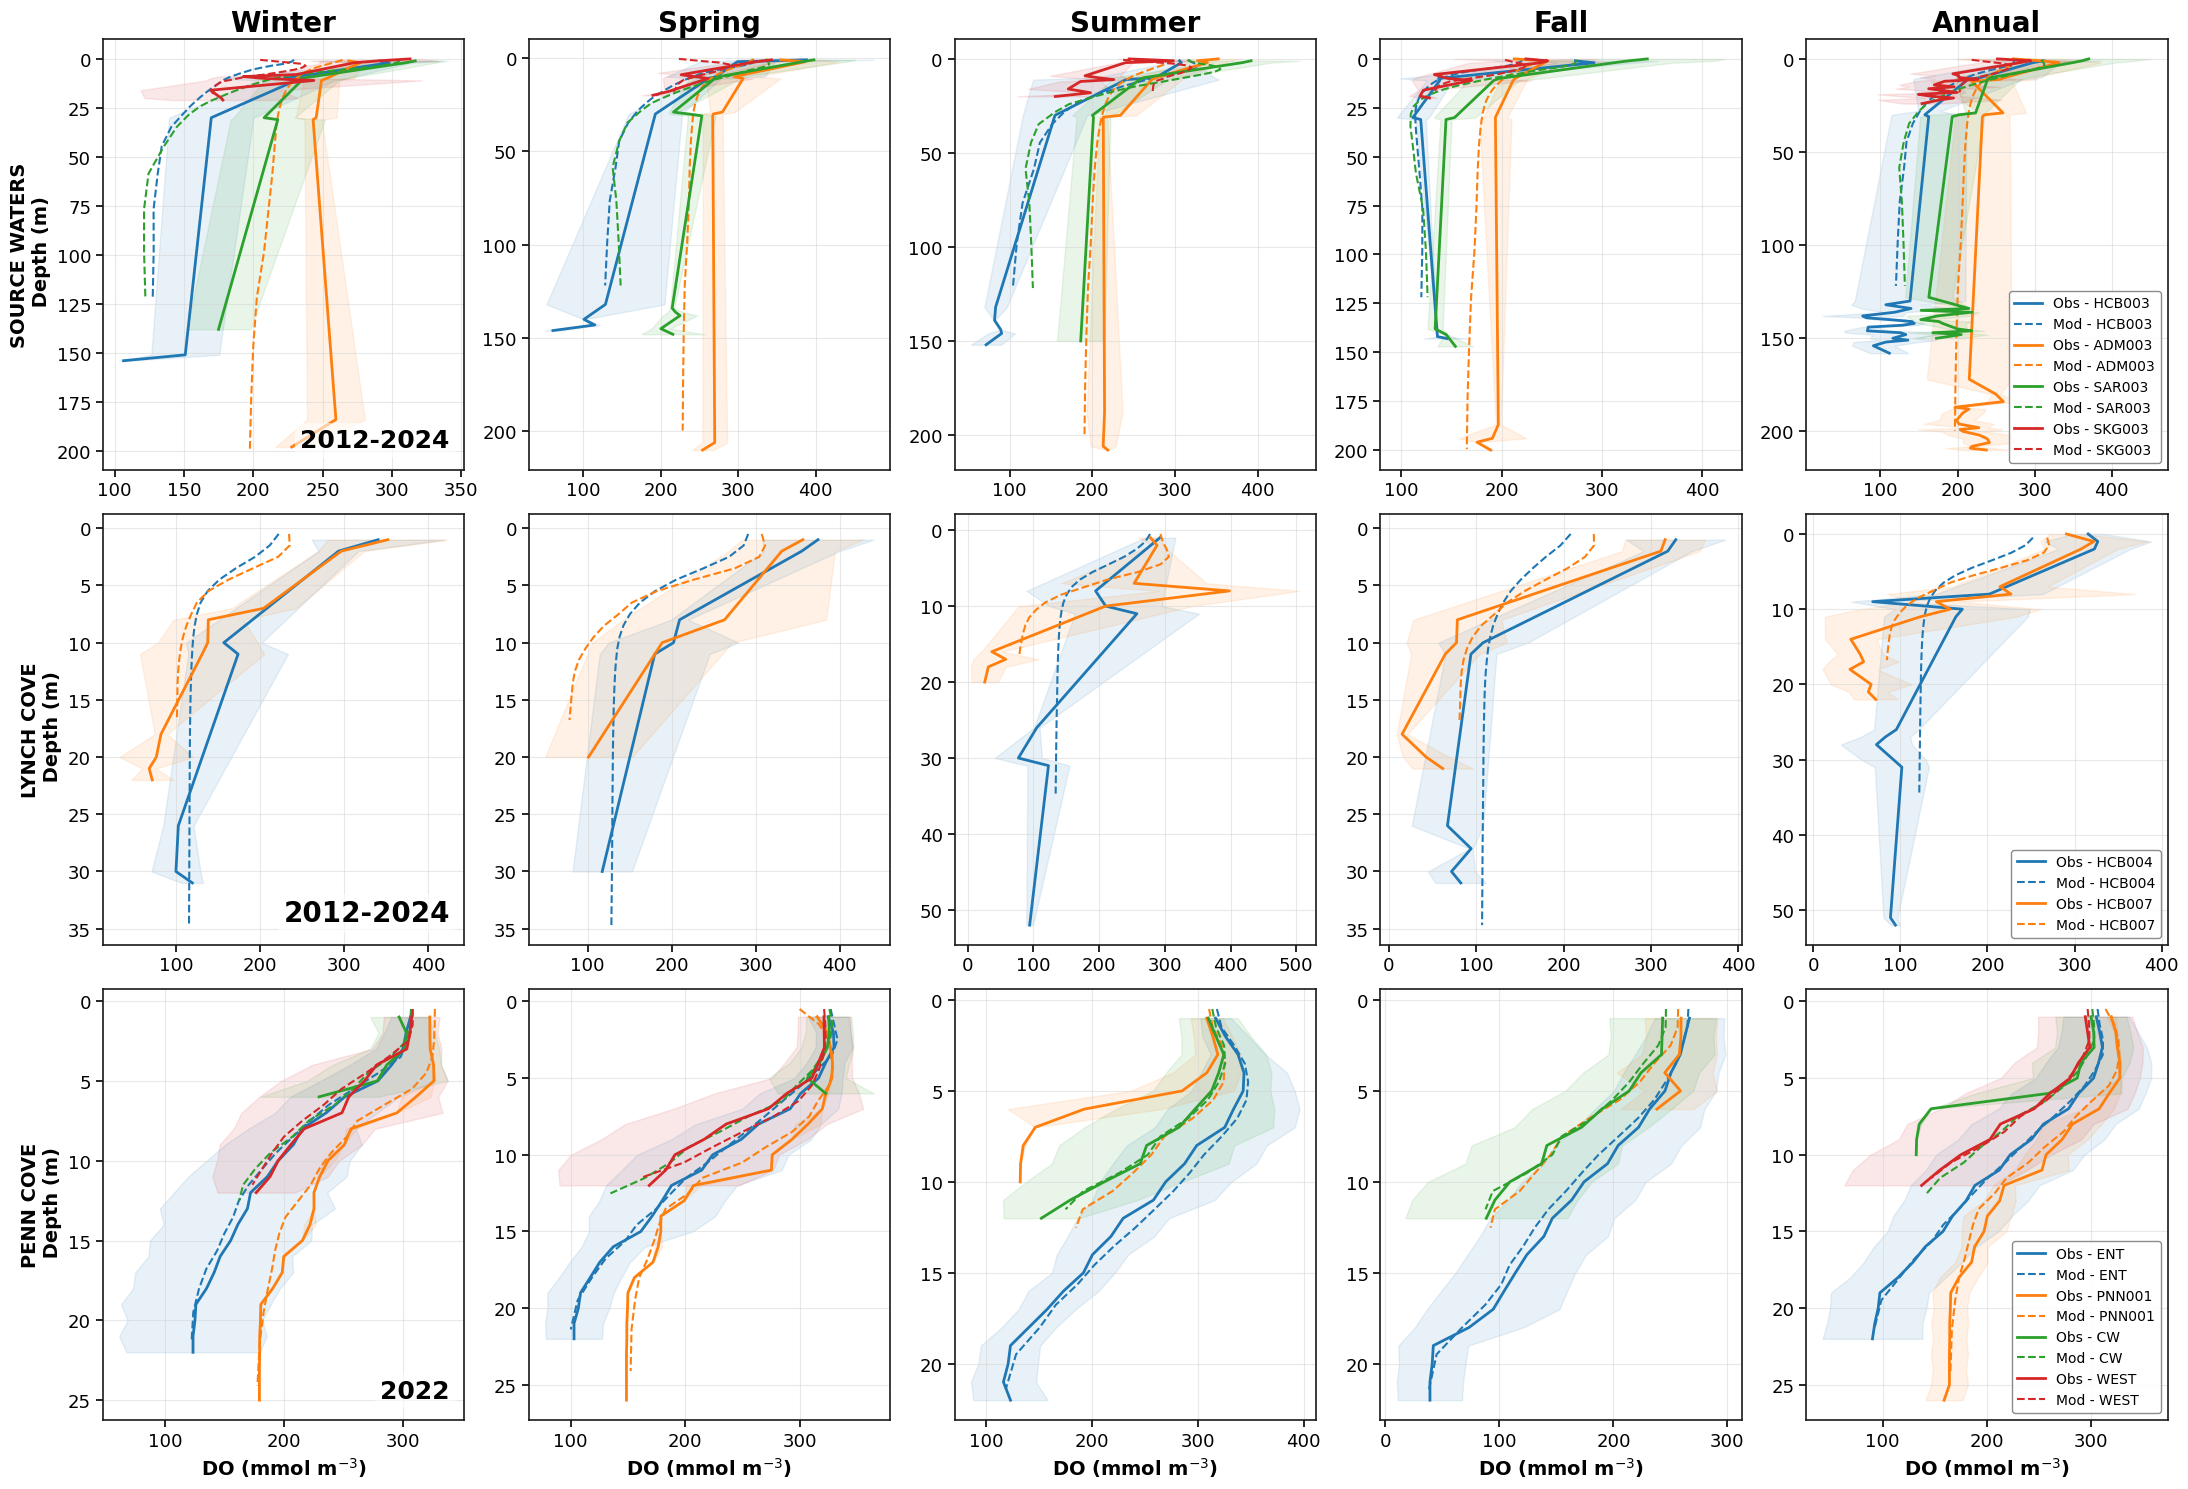

In [18]:
fig, axes = plt.subplots(3, 5, figsize=(22, 15), sharey=False)

########## Source Waters Stations
for i_col, col_name in enumerate(columns_list):
    ax = axes[0, i_col]
    ax.cla()

    for station_nameSources in list_obs_sources:
        sub_obs_sources = obs[obs["name"] == station_nameSources]

        # Seasonal filtering of obs
        if col_name == "Annual":
            obs_dataSources = sub_obs_sources.copy()
        else:
            obs_dataSources = sub_obs_sources[sub_obs_sources["season"] == col_name].copy()

        if not obs_dataSources.empty:
            obs_dataSources["Z_round"] = obs_dataSources["Z"].round()
            stats_obs_Sources = obs_dataSources.groupby("Z_round")["Oxygen_Dissolved"].agg(["mean", "std"]).dropna()

            if not stats_obs_Sources.empty:
                p, = ax.plot(stats_obs_Sources["mean"], stats_obs_Sources.index, lw=2, label=f"Obs - {station_nameSources}")
                color = p.get_color()

                # Spread (mean ± std)
                ax.fill_betweenx(stats_obs_Sources.index, stats_obs_Sources["mean"] - stats_obs_Sources["std"], stats_obs_Sources["mean"] + stats_obs_Sources["std"], color=color, alpha=0.1)

                # Model, daily (targeted on deptht)
                if station_nameSources in station_indices_Sources:
                    jj, ii = station_indices_Sources[station_nameSources]
                    k_bottom = int(mbathy0[0, jj, ii] - 1)
                    
                    # Unique list of days corresponding to the obs
                    unique_days = pd.to_datetime(obs_dataSources["dtUTC"].dt.date.unique())
                    
                    all_daily_profiles_Sources = []
                    mod_depths = None

                    for day_dt in unique_days:
                        year = day_dt.year
                        yr2 = day_dt.strftime("%y")
                        month = day_dt.month
                        Month = day_dt.strftime("%b").lower()
                        day = day_dt.day

                        fchem = (
                            f"{sim_dir}{day:02}{Month}{yr2}/"
                            f"SalishSea_1d_"
                            f"{year}{month:02}{day:02}_"
                            f"{year}{month:02}{day:02}_chem_T.nc"
                        )

                        if os.path.exists(fchem):
                            with xr.open_dataset(fchem) as ds_chem:
                                profile_val = ds_chem["dissolved_oxygen"][0, :, jj, ii].values
                                all_daily_profiles_Sources.append(profile_val)
                                if mod_depths is None:
                                    mod_depths = ds_chem["deptht"].values
                        else:
                            print(f"File not found: {fchem}")

                    if all_daily_profiles_Sources and mod_depths is not None:
                        mean_profile_Sources = np.mean(np.array(all_daily_profiles_Sources), axis=0)
                        
                        # Only plot the water column (up to k_bottom)
                        mod_profile_water_sources = mean_profile_Sources[: k_bottom + 1]
                        mod_depths_water_sources = mod_depths[: k_bottom + 1]

                        ax.plot(mod_profile_water_sources, mod_depths_water_sources, color=color, ls="--", lw=1.5, label=f"Mod - {station_nameSources}")

    # Formating
    ax.invert_yaxis()
    ax.grid(True, linestyle="-", color="#d3d3d3", alpha=0.5, lw=0.8)
    ax.tick_params(axis="both", which="major", labelsize=13, colors="black", width=1.2, length=5)
    for spine in ax.spines.values(): spine.set_edgecolor("#1a1a1a"); spine.set_linewidth(1.2)
    ax.set_title(f"{col_name}", fontsize=20, fontweight="bold")
    if i_col == 0: 
        ax.set_ylabel("SOURCE WATERS\n Depth (m)", fontsize=14, fontweight="bold")
        ax.text(0.96, 0.04, "2012-2024", transform=ax.transAxes, fontsize=18, fontweight="bold", va="bottom", ha="right", bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    if col_name == "Annual": ax.legend(loc="lower right", fontsize=10, framealpha=0.9, edgecolor="gray")


########## LYNCH COVE
for i_col, col_name in enumerate(columns_list):
    ax = axes[1, i_col]
    ax.cla()

    for station_name in list_obs:
        sub_obs = obs[obs["name"] == station_name]

        # Seasonal filtering of obs
        if col_name == "Annual":
            obs_data = sub_obs.copy()
        else:
            obs_data = sub_obs[sub_obs["season"] == col_name].copy()

        if not obs_data.empty:
            obs_data["Z_round"] = obs_data["Z"].round()
            stats_obs = obs_data.groupby("Z_round")["Oxygen_Dissolved"].agg(["mean", "std"]).dropna()

            if not stats_obs.empty:
                p, = ax.plot(stats_obs["mean"], stats_obs.index, lw=2, label=f"Obs - {station_name}")
                color = p.get_color()

                # Spread (mean ± std)
                ax.fill_betweenx(stats_obs.index, stats_obs["mean"] - stats_obs["std"], stats_obs["mean"] + stats_obs["std"], color=color, alpha=0.1)

                # Model, daily (targeted on deptht)
                if station_name in station_indices:
                    jj, ii = station_indices[station_name]
                    k_bottom = int(mbathy0[0, jj, ii] - 1)
                    
                    # Unique list of days corresponding to the obs
                    unique_days = pd.to_datetime(obs_data["dtUTC"].dt.date.unique())
                    
                    all_daily_profiles = []
                    mod_depths = None

                    for day_dt in unique_days:
                        year = day_dt.year
                        yr2 = day_dt.strftime("%y")
                        month = day_dt.month
                        Month = day_dt.strftime("%b").lower()
                        day = day_dt.day

                        fchem = (
                            f"{sim_dir}{day:02}{Month}{yr2}/"
                            f"SalishSea_1d_"
                            f"{year}{month:02}{day:02}_"
                            f"{year}{month:02}{day:02}_chem_T.nc"
                        )

                        if os.path.exists(fchem):
                            with xr.open_dataset(fchem) as ds_chem:
                                profile_val = ds_chem["dissolved_oxygen"][0, :, jj, ii].values
                                all_daily_profiles.append(profile_val)
                                if mod_depths is None:
                                    mod_depths = ds_chem["deptht"].values
                        else:
                            print(f"File not found: {fchem}")

                    if all_daily_profiles and mod_depths is not None:
                        mean_profile = np.mean(np.array(all_daily_profiles), axis=0)
                        
                        # Only plot the water column (up to k_bottom)
                        mod_profile_water = mean_profile[: k_bottom + 1]
                        mod_depths_water = mod_depths[: k_bottom + 1]

                        ax.plot(mod_profile_water, mod_depths_water, color=color, ls="--", lw=1.5, label=f"Mod - {station_name}")

    # Formating
    ax.invert_yaxis()
    ax.grid(True, linestyle="-", color="#d3d3d3", alpha=0.5, lw=0.8)
    ax.tick_params(axis="both", which="major", labelsize=13, colors="black", width=1.2, length=5)
    for spine in ax.spines.values(): spine.set_edgecolor("#1a1a1a"); spine.set_linewidth(1.2)
    #ax.set_title(f"{col_name}", fontsize=20, fontweight="bold")
    if i_col == 0: 
        ax.set_ylabel("LYNCH COVE\n Depth (m)", fontsize=14, fontweight="bold")
        ax.text(0.96, 0.04, "2012-2024", transform=ax.transAxes, fontsize=20, fontweight="bold", va="bottom", ha="right", bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    if col_name == "Annual": ax.legend(loc="lower right", fontsize=10, framealpha=0.9, edgecolor="gray")


########## PENN COVE
for i_col, col_name in enumerate(columns_list):
    ax = axes[2, i_col]
    ax.cla()

    for station_namePC in list_obs_pc:
        sub_obs_pc = obs_pc[obs_pc["Locator"] == station_namePC]

        # Seasonal filtering of obs
        if col_name == "Annual":
            obs_pc_data = sub_obs_pc.copy()
        else:
            obs_pc_data = sub_obs_pc[sub_obs_pc["season"] == col_name].copy()

        if not obs_pc_data.empty:
            obs_pc_data["Z_round"] = obs_pc_data["Z"].round()
            stats_pc = obs_pc_data.groupby("Z_round")["mod_dissolved_oxygen"].agg(["mean", "std"]).dropna()

            if not stats_pc.empty:
                clean_label = station_namePC.replace("PENNCOVE", "").lstrip("-_ ")
                if clean_label == "": clean_label = station_namePC

                # Spread (mean ± std)
                p, = ax.plot(stats_pc["mean"], stats_pc.index, lw=2, label=f"Obs - {clean_label}")
                color = p.get_color()

                ax.fill_betweenx(stats_pc.index, stats_pc["mean"] - stats_pc["std"], stats_pc["mean"] + stats_pc["std"], color=color, alpha=0.1)

                # Model, daily (targeted on deptht)
                if station_namePC in station_indicesPC:
                    jj, ii = station_indicesPC[station_namePC]
                    k_bottom_pc = int(mbathy0[0, jj, ii] - 1)
                    
                    # 
                    unique_days_pc = pd.to_datetime(obs_pc_data["dtUTC"].dt.date.unique())
                    
                    all_daily_profiles_pc = []
                    mod_depths_pc = None

                    for day_dt in unique_days_pc:
                        year = day_dt.year
                        yr2 = day_dt.strftime("%y")
                        month = day_dt.month
                        Month = day_dt.strftime("%b").lower()
                        day = day_dt.day

                        fchem = (
                            f"{sim_dir}{day:02}{Month}{yr2}/"
                            f"SalishSea_1d_"
                            f"{year}{month:02}{day:02}_"
                            f"{year}{month:02}{day:02}_chem_T.nc"
                        )

                        if os.path.exists(fchem):
                            with xr.open_dataset(fchem) as ds_chem:
                                # CORRECTION ICI : Axe vertical indexé
                                profile_val = ds_chem["dissolved_oxygen"][0, :, jj, ii].values
                                all_daily_profiles_pc.append(profile_val)
                                if mod_depths_pc is None:
                                    # CORRECTION ICI : deptht au lieu de depth
                                    mod_depths_pc = ds_chem["deptht"].values
                        else:
                            print(f"Fichier manquant ignoré : {fchem}")

                    if all_daily_profiles_pc and mod_depths_pc is not None:
                        mean_profile_pc = np.mean(np.array(all_daily_profiles_pc), axis=0)
                        
                        mod_profile_pc_water = mean_profile_pc[: k_bottom_pc + 1]
                        mod_depths_pc_water = mod_depths_pc[: k_bottom_pc + 1]

                        ax.plot(mod_profile_pc_water, mod_depths_pc_water, color=color, ls="--", lw=1.5, label=f"Mod - {clean_label}")

    # Formating
    ax.invert_yaxis()
    ax.grid(True, linestyle="-", color="#d3d3d3", alpha=0.5, lw=0.8)
    ax.tick_params(axis="both", which="major", labelsize=13, colors="black", width=1.2, length=5)
    for spine in ax.spines.values(): spine.set_edgecolor("#1a1a1a"); spine.set_linewidth(1.2)
    ax.set_xlabel("DO (mmol m$^{-3}$)", fontsize=14, fontweight="bold")
    if i_col == 0: 
        ax.set_ylabel("PENN COVE\n Depth (m)", fontsize=14, fontweight="bold")
        ax.text(0.96, 0.04, "2022", transform=ax.transAxes, fontsize=18, fontweight="bold", va="bottom", ha="right", bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    if col_name == "Annual": ax.legend(loc="lower right", fontsize=10, framealpha=0.9, edgecolor="gray")

plt.tight_layout()
plt.show()
